In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.discrete.count_model import ZeroInflatedNegativeBinomialP


In [2]:
future_df = pd.read_csv("/Users/rhombus19/projects/eleo/future_features_dataset.csv")
train_df = pd.read_csv("/Users/rhombus19/projects/eleo/forecast_dataset.csv")

In [3]:
train_df["date"] = pd.to_datetime(train_df["date"])
train_df = train_df.sort_values(["SKU", "date"]).reset_index(drop=True)


In [4]:
train_df

,date,SKU,qty,price_per_unit,tavg,prcp,tsun,sale_active,sale_percent,mmdd,day_of_week,month,is_holiday
0,2024-01-26,9101dx,2.0,1522.660000,9.0,1.2,0.0,True,0.24,01-26,4,1,False
1,2024-01-27,9101dx,0.0,1295.228583,3.0,0.0,510.0,True,0.24,01-27,5,1,False
2,2024-01-28,9101dx,0.0,1295.228583,3.7,0.0,516.0,True,0.24,01-28,6,1,False
3,2024-01-29,9101dx,2.0,1449.580000,5.5,0.0,492.0,True,0.24,01-29,0,1,False
4,2024-01-30,9101dx,1.0,1449.580000,6.1,0.0,192.0,True,0.24,01-30,1,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
149851,2025-11-20,sz21032,0.0,74.790000,2.3,0.0,59.0,False,0.00,11-20,3,11,False
149852,2025-11-21,sz21032,0.0,74.790000,-1.0,0.0,136.0,False,0.00,11-21,4,11,False
149853,2025-11-22,sz21032,0.0,74.790000,-4.2,0.0,243.0,False,0.00,11-22,5,11,False
149854,2025-11-23,sz21032,0.0,74.790000,-2.6,2.5,155.0,False,0.00,11-23,6,11,False


In [5]:
sku = "9101dx"   # example

sku_hist = train_df[train_df["SKU"] == sku].copy()
sku_hist = sku_hist.sort_values("date").reset_index(drop=True)

# sanity check: if no sales at all, skip this SKU
if sku_hist["qty"].sum() == 0:
    raise ValueError("No non-zero sales for this SKU – cannot fit a useful ZINB.")


In [7]:
sku_hist

,date,SKU,qty,price_per_unit,tavg,prcp,tsun,sale_active,sale_percent,mmdd,day_of_week,month,is_holiday
0,2024-01-26,9101dx,2.0,1522.660000,9.0,1.2,0.0,True,0.24,01-26,4,1,False
1,2024-01-27,9101dx,0.0,1295.228583,3.0,0.0,510.0,True,0.24,01-27,5,1,False
2,2024-01-28,9101dx,0.0,1295.228583,3.7,0.0,516.0,True,0.24,01-28,6,1,False
3,2024-01-29,9101dx,2.0,1449.580000,5.5,0.0,492.0,True,0.24,01-29,0,1,False
4,2024-01-30,9101dx,1.0,1449.580000,6.1,0.0,192.0,True,0.24,01-30,1,1,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
664,2025-11-20,9101dx,0.0,1295.228583,2.3,0.0,59.0,True,0.20,11-20,3,11,False
665,2025-11-21,9101dx,0.0,1295.228583,-1.0,0.0,136.0,True,0.20,11-21,4,11,False
666,2025-11-22,9101dx,0.0,1295.228583,-4.2,0.0,243.0,True,0.20,11-22,5,11,False
667,2025-11-23,9101dx,0.0,1295.228583,-2.6,2.5,155.0,True,0.20,11-23,6,11,False


In [14]:
# convert to numeric types we like
for col in ["is_holiday"]:
    sku_hist[col] = sku_hist[col].astype(int)

num_cols = ["tavg", "prcp", "tsun", "price_per_unit", "sale_percent"]
cat_cols = ["day_of_week", "month"]  # already ints in your data
bin_cols = ["is_holiday"]

# ----- design matrix for count process -----
X = sku_hist[num_cols + cat_cols + bin_cols].copy()

# one-hot encode categorical calendar fields
X = pd.get_dummies(
    X,
    columns=cat_cols,
    drop_first=True  # avoid dummy trap
)

# add intercept
X = sm.add_constant(X, has_constant="add")

# target
y = sku_hist["qty"].astype(int).to_numpy()

# ----- design matrix for zero-inflation (logit) part -----
Z = sku_hist[["sale_percent", "is_holiday"]].copy()
Z = sm.add_constant(Z, has_constant="add")


In [24]:
X = X.fillna(0.0)
Z = Z.fillna(0.0)

X = X.astype(float)
Z = Z.astype(float)


In [25]:
zinb_model = ZeroInflatedNegativeBinomialP(
    endog=y,
    exog=np.asarray(X),
    exog_infl=Z,
    inflation="logit"  # logit model for the extra zeros
)

zinb_res = zinb_model.fit(maxiter=200, method="lbfgs", disp=False)
print(zinb_res.summary())


                     ZeroInflatedNegativeBinomialP Regression Results                    
Dep. Variable:                                 y   No. Observations:                  669
Model:             ZeroInflatedNegativeBinomialP   Df Residuals:                      645
Method:                                      MLE   Df Model:                           23
Date:                           Sat, 29 Nov 2025   Pseudo R-squ.:                 -0.1969
Time:                                   15:48:09   Log-Likelihood:                -418.80
converged:                                 False   LL-Null:                       -349.90
Covariance Type:                       nonrobust   LLR p-value:                     1.000
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
inflate_const                 0        nan        nan        nan         nan         nan
inflate_sale_

/Users/rhombus19/projects/eleo/eleo-mind/packages/backend/.venv/lib/python3.11/site-packages/statsmodels/base/model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
/Users/rhombus19/projects/eleo/eleo-mind/packages/backend/.venv/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:4329: RuntimeWarning: overflow encountered in exp
  return np.exp(linpred)
/Users/rhombus19/projects/eleo/eleo-mind/packages/backend/.venv/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:3937: RuntimeWarning: invalid value encountered in multiply
  a1 * np.log(a1) + y * np.log(mu) -
/Users/rhombus19/projects/eleo/eleo-mind/packages/backend/.venv/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:3936: RuntimeWarning: invalid value encountered in subtract
  llf = (gammaln(y + a1) - gammaln(y + 1) - gammaln(a1) +
/Users/rhombus19/projects/eleo/eleo-mind/p

In [6]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

import statsmodels.api as sm
from statsmodels.discrete.count_model import ZeroInflatedNegativeBinomialP


# create integer holiday flag
sku_hist["is_holiday_int"] = sku_hist["is_holiday"].astype(int)

# choose a *small* feature set for now
cont_cols = ["tavg", "price_per_unit", "sale_percent"]
# you can later add ["prcp", "tsun"] once this is stable

needed = ["qty"] + cont_cols + ["is_holiday_int"]
sku_hist = sku_hist.dropna(subset=needed)

# target: counts as int
y = sku_hist["qty"].astype(int).to_numpy()

print("Unique y:", np.unique(y), "sum:", y.sum(), "max:", y.max())


Unique y: [0 1 2 3] sum: 128 max: 3


In [7]:
scaler = StandardScaler()
sku_hist[cont_cols] = scaler.fit_transform(sku_hist[cont_cols])


In [8]:
X = sku_hist[cont_cols + ["is_holiday_int"]].copy()
X = sm.add_constant(X, has_constant="add")   # adds 'const' column
print("X columns:", X.columns.tolist())


X columns: ['const', 'tavg', 'price_per_unit', 'sale_percent', 'is_holiday_int']


In [9]:
Z = pd.DataFrame({"const": 1.0}, index=sku_hist.index)
print("Z columns:", Z.columns.tolist())


Z columns: ['const']


In [10]:
zinb_model = ZeroInflatedNegativeBinomialP(
    endog=y,
    exog=X,
    exog_infl=Z,      # only intercept for inflation part
    inflation="logit" # logit model for structural zero probability
)

zinb_res = zinb_model.fit(maxiter=200, method="bfgs", disp=True)
print(zinb_res.summary())


         Current function value: nan
         Iterations: 33
         Function evaluations: 144
         Gradient evaluations: 144
                     ZeroInflatedNegativeBinomialP Regression Results                    
Dep. Variable:                                 y   No. Observations:                  669
Model:             ZeroInflatedNegativeBinomialP   Df Residuals:                      664
Method:                                      MLE   Df Model:                            4
Date:                           Sat, 29 Nov 2025   Pseudo R-squ.:                     nan
Time:                                   15:55:17   Log-Likelihood:                    nan
converged:                                 False   LL-Null:                       -349.90
Covariance Type:                       nonrobust   LLR p-value:                       nan
                     coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------

/Users/rhombus19/projects/eleo/eleo-mind/packages/backend/.venv/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:3937: RuntimeWarning: invalid value encountered in log
  a1 * np.log(a1) + y * np.log(mu) -
/Users/rhombus19/projects/eleo/eleo-mind/packages/backend/.venv/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:3938: RuntimeWarning: invalid value encountered in log
  (y + a1) * np.log(a2))
/Users/rhombus19/projects/eleo/eleo-mind/packages/backend/.venv/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:3974: RuntimeWarning: invalid value encountered in log
  dgterm = dgpart + np.log(a1 / a2) + 1 - a3 / a2
/Users/rhombus19/projects/eleo/eleo-mind/packages/backend/.venv/lib/python3.11/site-packages/statsmodels/discrete/discrete_model.py:4329: RuntimeWarning: overflow encountered in exp
  return np.exp(linpred)
/Users/rhombus19/projects/eleo/eleo-mind/packages/backend/.venv/lib/python3.11/site-packages/statsmodels/discrete/discre

In [11]:
import statsmodels.api as sm
from statsmodels.discrete.discrete_model import NegativeBinomial
from statsmodels.discrete.discrete_model import Poisson

# X, y as we already defined (standardized cont_cols + is_holiday_int)
# ------------------------------------------
# Poisson
pois_model = Poisson(y, X)
pois_res = pois_model.fit(method="bfgs", maxiter=200, disp=True)
print(pois_res.summary())

# Negative Binomial (optional)
nb_model = NegativeBinomial(y, X)
nb_res = nb_model.fit(method="bfgs", maxiter=200, disp=True)
print(nb_res.summary())


Optimization terminated successfully.
         Current function value: 0.526568
         Iterations: 21
         Function evaluations: 22
         Gradient evaluations: 22
                          Poisson Regression Results                          
Dep. Variable:                      y   No. Observations:                  669
Model:                        Poisson   Df Residuals:                      664
Method:                           MLE   Df Model:                            4
Date:                Sat, 29 Nov 2025   Pseudo R-squ.:                 0.01661
Time:                        15:58:16   Log-Likelihood:                -352.27
converged:                       True   LL-Null:                       -358.23
Covariance Type:            nonrobust   LLR p-value:                   0.01809
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -1.6499     

In [16]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import PoissonRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import PoissonRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error

X_hist = sku_hist[cont_cols + cat_cols]
y_hist = sku_hist["qty"].astype(int)
sale_flag = (y_hist > 0).astype(int)

# shared preprocessor
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), cont_cols),
        ("cat", "passthrough", cat_cols),
    ]
)

# 1) classifier
clf = Pipeline([
    ("pre", preprocess),
    ("model", GradientBoostingClassifier())
])
clf.fit(X_hist, sale_flag)

# 2) regressor on positive days
mask_pos = y_hist > 0
reg = Pipeline([
    ("pre", preprocess),
    ("model", PoissonRegressor(alpha=1.0, max_iter=1000))
])
reg.fit(X_hist[mask_pos], y_hist[mask_pos])

# --- forecast ---
sku_future = future_df[future_df["SKU"] == "9101dx"].copy()
sku_future = sku_future.sort_values("date").iloc[:100].reset_index(drop=True)
sku_future["is_holiday_int"] = sku_future["is_holiday"].astype(int)

X_future = sku_future[cont_cols + cat_cols]

p_sale = clf.predict_proba(X_future)[:, 1]
qty_if_sale = reg.predict(X_future)

qty_expected = p_sale * qty_if_sale

sku_forecast = pd.DataFrame({
    "SKU": "9101dx",
    "date": sku_future["date"],
    "qty_pred": qty_expected
})


<Axes: xlabel='date'>

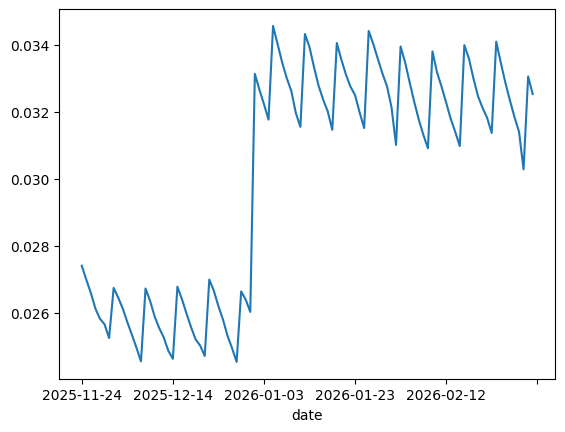

In [20]:
sku_forecast.set_index("date")["qty_pred"].plot()